# Seasonal Agriculture Performance Analysis

This notebook explores, cleans, analyzes, and visualizes seasonal agriculture performance across Kharif, Rabi, and Zaid seasons.

In [1]:
import os
from pathlib import Path
import warnings

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib-cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load and Explore the Data

In [2]:
DATA_PATH = Path('seasonal_agriculture_performance_dataset.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Expected data file at {DATA_PATH.resolve()}')

raw = pd.read_csv(DATA_PATH)
df = raw.copy()

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())


Dataset shape: 4,000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
print('Data types:')
display(df.dtypes.to_frame('dtype'))

print('Missing values by column:')
display(df.isna().sum().to_frame('missing_count').assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100))

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

unique_summary = pd.DataFrame({
    'column': categorical_cols,
    'unique_count': [df[col].nunique(dropna=True) for col in categorical_cols],
    'sample_values': [', '.join(map(str, df[col].dropna().unique()[:8])) for col in categorical_cols],
})
display(unique_summary)


Data types:


,dtype
Farm_ID,str
State,str
District,str
Crop,str
Season,str
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


Missing values by column:


,missing_count,missing_pct
Farm_ID,0,0.00
State,0,0.00
District,0,0.00
Crop,0,0.00
Season,0,0.00
Farm_Area_Hectares,0,0.00
Rainfall_mm,48,1.20
Avg_Temperature_C,0,0.00
Humidity_pct,0,0.00
Sunlight_Hours_Day,0,0.00


/tmp/ipykernel_37824/4039608197.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


,column,unique_count,sample_values
0,Farm_ID,4000,"SF10001, SF10002, SF10003, SF10004, SF10005, S..."
1,State,8,"Andhra Pradesh, Maharashtra, Telangana, Karnat..."
2,District,10,"Rajkot, Nalgonda, Warangal, Indore, Ludhiana, ..."
3,Crop,8,"Wheat, Maize, Pulses, Rice, Cotton, Chilli, Gr..."
4,Season,3,"Kharif, Rabi, Zaid"
5,Irrigation_Method,4,"Drip, Flood, Rainfed, Sprinkler"


In [4]:
print('Season counts:')
display(df['Season'].value_counts(dropna=False).to_frame('rows'))

print('Numeric summary:')
display(df[numeric_cols].describe().T)


Season counts:


,rows
Season,
Kharif,1779
Rabi,1627
Zaid,594


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 2. Clean the Data

In [5]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count:,}')
if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape after dropping duplicates: {df.shape}')


Duplicate rows found: 0


In [6]:
season_order = ['Kharif', 'Rabi', 'Zaid']
existing_seasons = [s for s in season_order if s in df['Season'].dropna().unique()]
if len(existing_seasons) != 3:
    print('Observed seasons:', sorted(df['Season'].dropna().unique()))

# Normalize obvious whitespace in categorical columns before grouped cleaning.
for col in categorical_cols:
    df[col] = df[col].astype('string').str.strip()
    df[col] = df[col].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

missing_before = df.isna().sum()

# Fill numeric values with medians computed within each season.
for col in numeric_cols:
    df[col] = df[col].fillna(df.groupby('Season')[col].transform('median'))
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Fill categorical values with modes computed within each season.
for col in categorical_cols:
    season_modes = df.groupby('Season')[col].transform(lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else pd.NA)
    df[col] = df[col].fillna(season_modes)
    if df[col].isna().any():
        global_mode = df[col].mode(dropna=True)
        df[col] = df[col].fillna(global_mode.iloc[0] if not global_mode.empty else 'Unknown')

missing_after = df.isna().sum()
cleaning_missing_report = pd.DataFrame({'before': missing_before, 'after': missing_after})
display(cleaning_missing_report[cleaning_missing_report['before'].gt(0) | cleaning_missing_report['after'].gt(0)])


,before,after
Rainfall_mm,48,0
Soil_Moisture_pct,40,0
Yield_Tonnes_Ha,32,0


In [7]:
def cap_seasonal_iqr(frame, column, lower_floor=None, iqr_multiplier=3.0):
    cleaned = frame[column].copy()
    report = []
    for season, idx in frame.groupby('Season').groups.items():
        vals = frame.loc[idx, column]
        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr
        if lower_floor is not None:
            lower = max(lower, lower_floor)
        mask = (vals < lower) | (vals > upper)
        cleaned.loc[idx] = vals.clip(lower=lower, upper=upper)
        report.append({
            'Season': season,
            'column': column,
            'lower_bound': lower,
            'upper_bound': upper,
            'values_capped': int(mask.sum()),
        })
    return cleaned, pd.DataFrame(report)

outlier_reports = []
for col in ['Yield_Tonnes_Ha', 'Production_Tonnes']:
    df[col], report = cap_seasonal_iqr(df, col, lower_floor=0, iqr_multiplier=3.0)
    outlier_reports.append(report)

outlier_report = pd.concat(outlier_reports, ignore_index=True)
display(outlier_report)

invalid_after = df[['Yield_Tonnes_Ha', 'Production_Tonnes']].le(0).sum().to_frame('non_positive_after_cleaning')
display(invalid_after)


,Season,column,lower_bound,upper_bound,values_capped
0,Kharif,Yield_Tonnes_Ha,0,8.86,119
1,Rabi,Yield_Tonnes_Ha,0,7.89,122
2,Zaid,Yield_Tonnes_Ha,0,6.54,49
3,Kharif,Production_Tonnes,0,92.41,110
4,Rabi,Production_Tonnes,0,74.75,111
5,Zaid,Production_Tonnes,0,66.77,43


,non_positive_after_cleaning
Yield_Tonnes_Ha,0
Production_Tonnes,0


## 3. Feature Engineering

In [8]:
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0, df['Profit_INR'] / df['Revenue_INR'] * 100, np.nan)
df['Cost_per_Tonne_INR'] = np.where(df['Production_Tonnes'] > 0, df['Total_Cost_INR'] / df['Production_Tonnes'], np.nan)

for col in ['Profit_Margin_pct', 'Cost_per_Tonne_INR']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df.groupby('Season')[col].transform('median'))
    df[col] = df[col].fillna(df[col].median())

display(df[['Season', 'Crop', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR', 'Profit_Margin_pct', 'Cost_per_Tonne_INR']].head())


,Season,Crop,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Profit_Margin_pct,Cost_per_Tonne_INR
0,Kharif,Wheat,2.46,1.30,-11852,30810,-38.47,"32,816.92"
1,Kharif,Maize,0.30,1.96,-451950,40401,"-1,118.66","251,199.49"
2,Rabi,Pulses,0.52,2.53,-124744,190466,-65.49,"124,588.93"
3,Kharif,Rice,1.84,8.28,-95704,200740,-47.68,"35,802.42"
4,Zaid,Maize,2.21,9.30,-144352,193607,-74.56,"36,339.68"


## 4. Seasonal Comparisons

In [9]:
environment_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
resource_cols = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
economic_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct', 'Cost_per_Tonne_INR']

def grouped_summary(columns):
    return df.groupby('Season')[columns].agg(['mean', 'median', 'std', 'min', 'max']).reindex(existing_seasons)

print('Environmental summary by season')
display(grouped_summary(environment_cols))
print('Resource usage summary by season')
display(grouped_summary(resource_cols))
print('Economic performance summary by season')
display(grouped_summary(economic_cols))


Environmental summary by season


Rainfall_mm                               Avg_Temperature_C         \
              mean median    std    min      max              mean median   
Season                                                                      
Kharif      852.11 854.75 181.57 160.50 1,395.20             28.45  28.50   
Rabi        435.94 430.30 174.69  80.00 1,146.50             23.49  23.50   
Zaid        299.12 283.30 152.56  80.00   708.30             31.04  31.00   

                        Humidity_pct                          \
        std   min   max         mean median  std   min   max   
Season                                                         
Kharif 2.51 19.40 36.80        71.81  71.90 8.86 36.90 95.00   
Rabi   2.46 16.20 31.10        57.89  58.10 9.00 25.00 86.30   
Zaid   2.55 24.50 39.70        52.01  52.35 9.05 25.00 79.50   

       Sunlight_Hours_Day                        Soil_pH                   \
                     mean median  std  min   max    mean median  std  min   
Season                                                                      
Kharif               6.79   6.80 0.98 3.50 10.30    6.73   6.73 0.64 5.20   
Rabi                 7.59   7.60 1.00 4.10 11.00    6.67   6.67 0.64 5.20   
Zaid                 8.18   8.20 1.05 4.70 11.00    6.69   6.66 0.64 5.20   

            Soil_Moisture_pct                          
        max              mean median  std   min   max  
Season                                                 
Kharif 8.40             31.20  31.20 5.02 12.70 47.00  
Rabi   8.40             24.05  24.00 4.94  8.00 39.90  
Zaid   8.40             19.17  19.10 4.86  8.00 33.60

Resource usage summary by season


Nitrogen_kg_ha                           Phosphorus_kg_ha               \
                 mean median   std   min    max             mean median   std   
Season                                                                          
Kharif         120.02 119.80 31.18 40.00 220.00            58.10  57.40 17.15   
Rabi           120.40 120.30 31.10 40.00 220.00            57.31  57.70 17.12   
Zaid           120.53 120.15 31.70 40.00 220.00            58.13  57.45 16.29   

                    Potassium_kg_ha                            \
         min    max            mean median   std   min    max   
Season                                                          
Kharif 15.00 120.00          105.30 104.80 27.03 30.00 184.00   
Rabi   15.00 120.00          103.93 104.80 28.87 30.00 200.00   
Zaid   15.00 112.20          105.42 106.30 26.66 32.60 176.70   

       Fertilizer_kg_ha                           Pesticide_Litre_ha         \
                   mean median   std   min    max               mean median   
Season                                                                        
Kharif           187.08 188.20 60.82 40.00 381.30               5.08   5.18   
Rabi             185.41 185.30 59.95 40.00 400.00               5.02   5.02   
Zaid             184.64 183.95 59.47 40.00 400.00               5.17   5.19   

                       Water_Used_m3                                \
        std  min   max          mean   median      std  min    max   
Season                                                               
Kharif 1.96 0.50 11.80      6,102.20 4,469.00 5,670.58  139  36156   
Rabi   1.99 0.50 12.08      5,846.99 4,292.00 5,397.65  128  40902   
Zaid   1.99 0.50 11.78      6,419.89 4,805.00 5,734.62  182  34392   

       Water_Efficiency_t_per_1000m3                         
                                mean median  std  min   max  
Season                                                       
Kharif                          5.89   3.28 9.83 0.14 79.80  
Rabi                            5.19   2.74 8.26 0.15 75.34  
Zaid                            4.41   2.30 6.93 0.14 48.55

Economic performance summary by season


Yield_Tonnes_Ha                       Production_Tonnes               \
                  mean median  std  min  max              mean median   std   
Season                                                                        
Kharif            2.48   1.95 2.05 0.30 8.86             21.10  13.24 23.02   
Rabi              2.21   1.66 1.90 0.30 7.89             18.10  11.08 19.55   
Zaid              1.89   1.45 1.62 0.30 6.54             16.03   9.97 17.42   

                  Total_Cost_INR                                        \
        min   max           mean     median        std    min      max   
Season                                                                   
Kharif 0.20 92.41     531,804.41 524,840.00 298,487.69  30901  1297725   
Rabi   0.19 74.75     513,836.58 506,733.00 288,386.89  27026  1349990   
Zaid   0.15 66.77     543,976.73 534,833.00 297,576.86  26826  1258745   

       Revenue_INR                                      Profit_INR             \
              mean     median        std   min      max       mean     median   
Season                                                                          
Kharif  710,719.06 520,196.00 708,710.37  8760  5080900 178,914.65  38,808.00   
Rabi    601,526.05 438,156.00 584,545.52  6107  4350998  87,689.47  -3,187.00   
Zaid    519,171.90 373,700.50 509,524.55  6709  3502589 -24,804.82 -62,144.00   

                                    Profit_Margin_pct                          \
              std      min      max              mean median    std       min   
Season                                                                          
Kharif 611,549.78  -976860  4345421            -38.64  11.09 170.62 -1,461.85   
Rabi   489,901.25 -1019223  3378879            -44.27  -1.34 144.37 -1,033.08   
Zaid   436,356.75  -965197  2349990            -69.35 -24.59 152.90 -1,040.32   

             Cost_per_Tonne_INR                                          
         max               mean    median       std      min        max  
Season                                                                   
Kharif 85.92          51,857.45 34,278.88 52,593.11   773.73 296,805.13  
Rabi   82.43          56,402.95 39,741.57 52,147.80 1,210.06 295,982.23  
Zaid   76.65          67,398.27 45,445.95 60,488.83 1,346.89 292,204.91

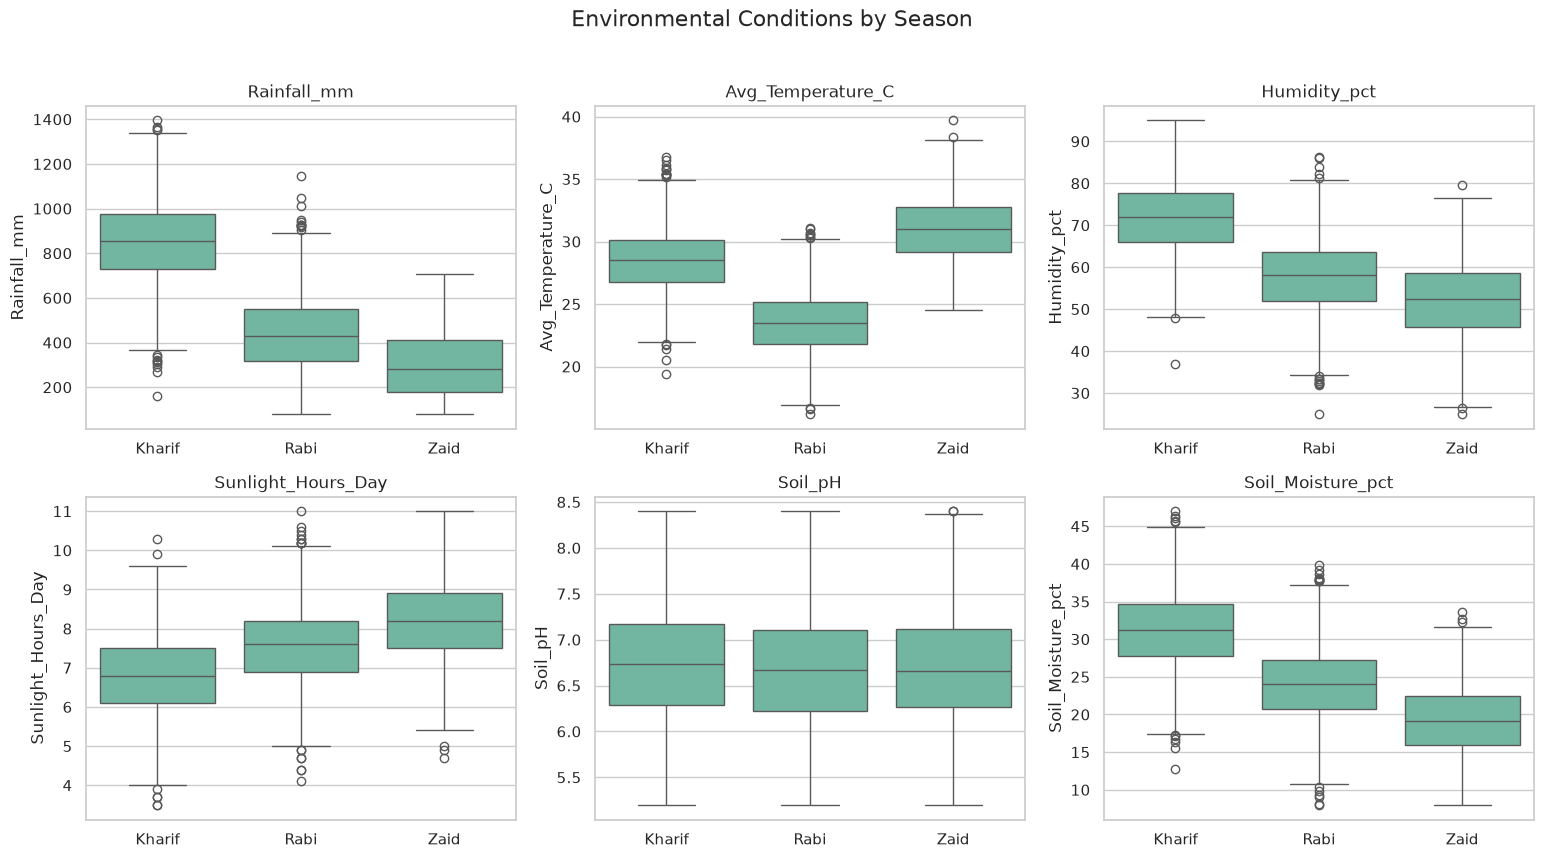

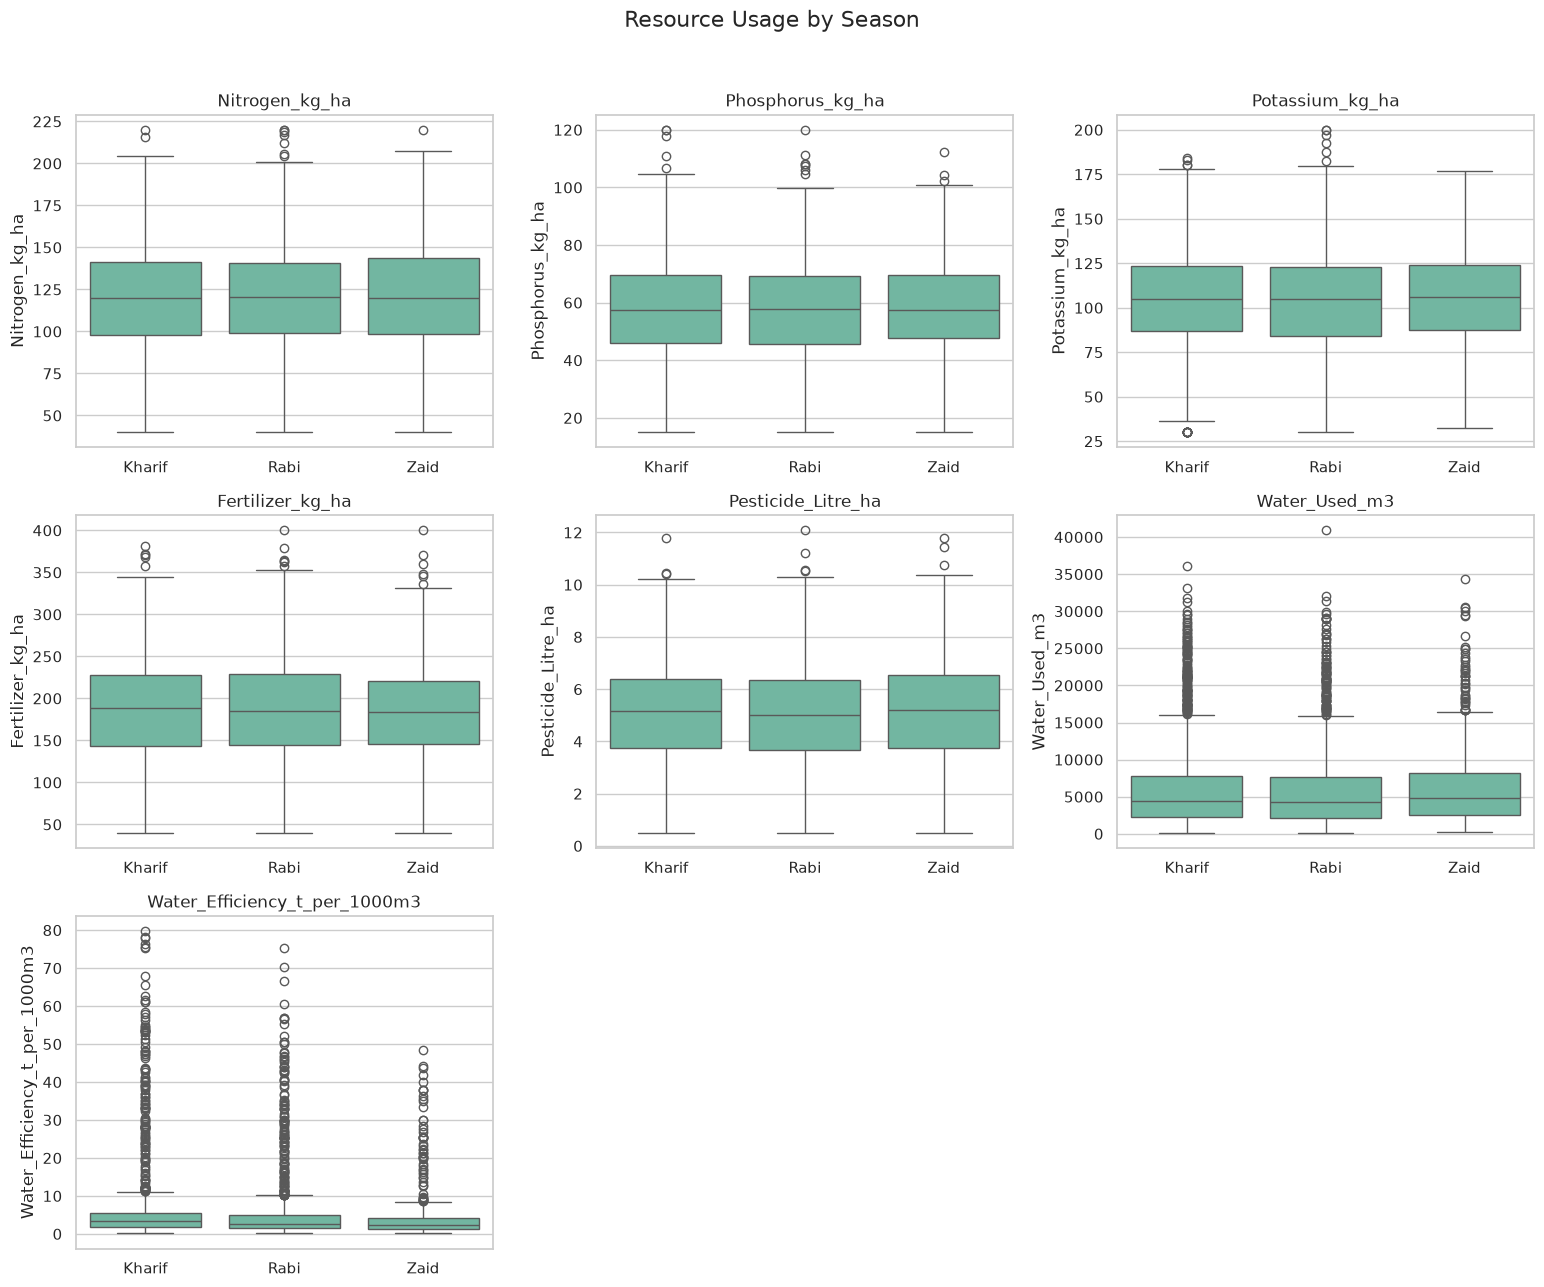

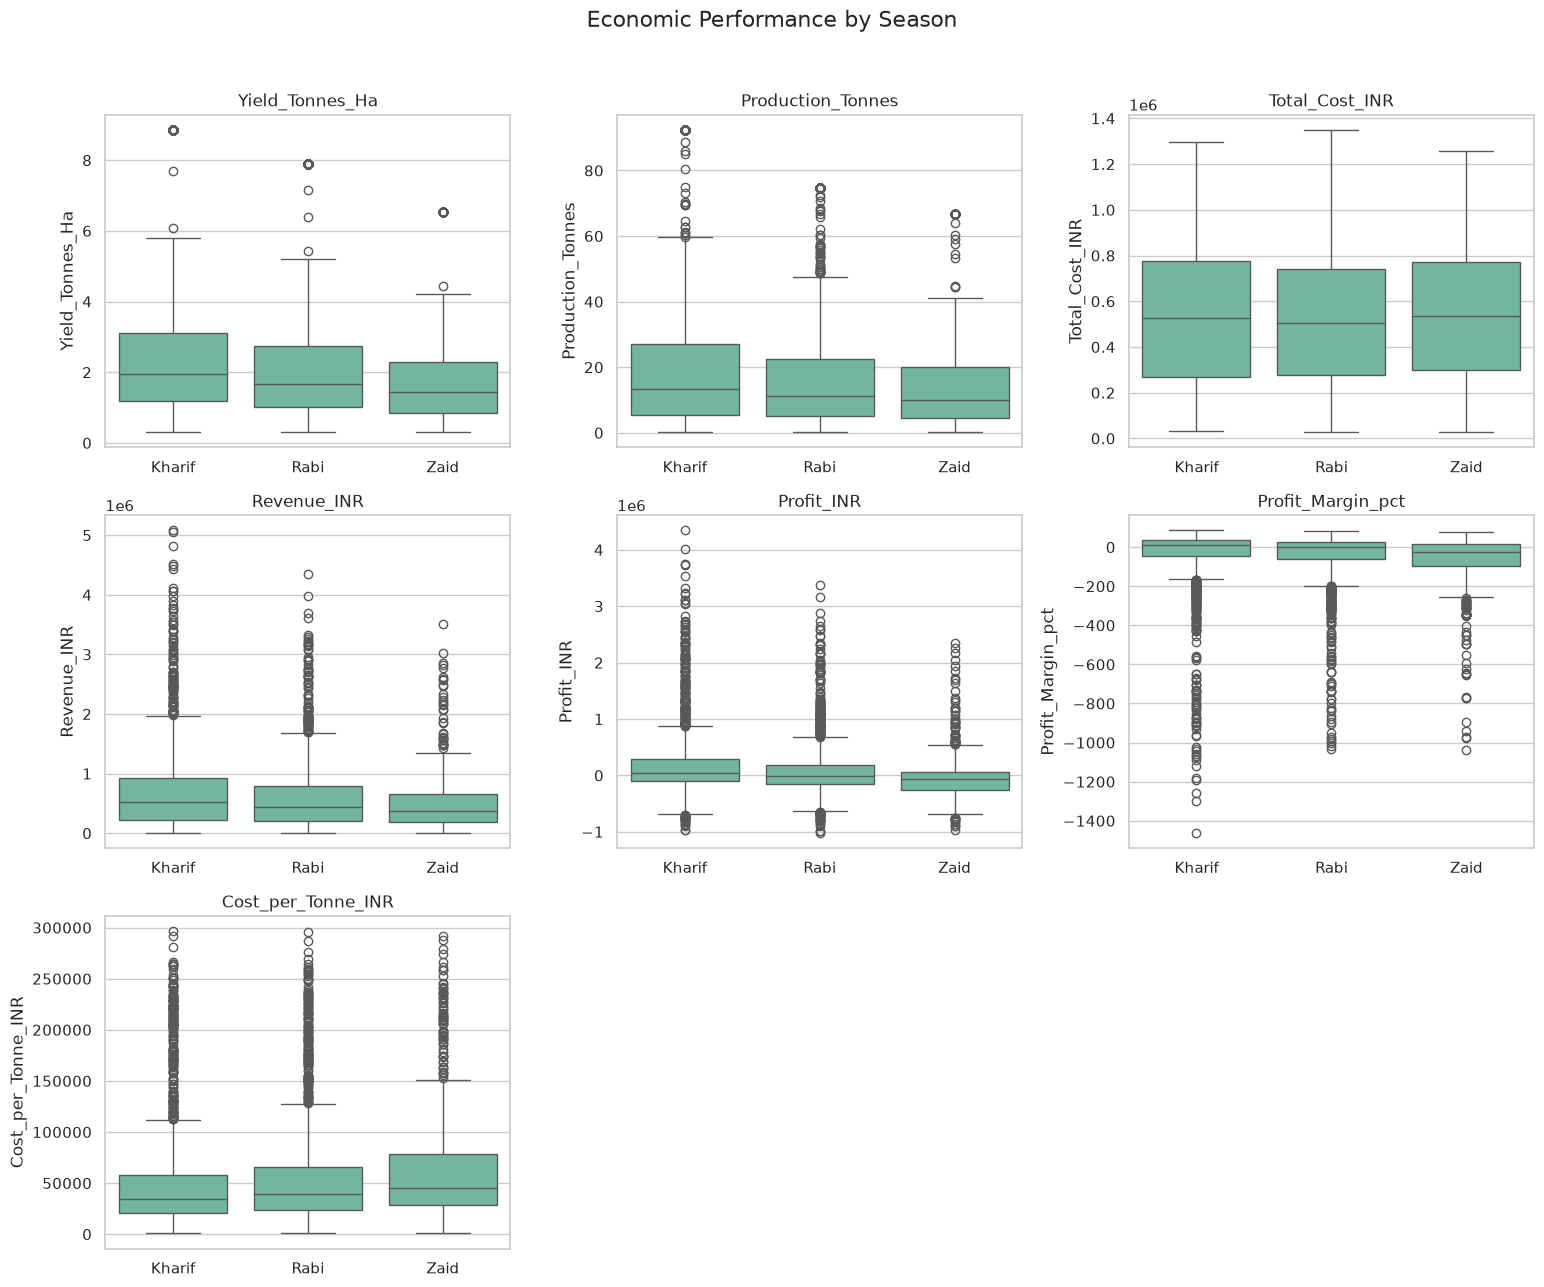

In [10]:
def plot_box_grid(columns, title, ncols=3):
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        sns.boxplot(data=df, x='Season', y=col, order=existing_seasons, ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
    for ax in axes[len(columns):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_box_grid(environment_cols, 'Environmental Conditions by Season')
plot_box_grid(resource_cols, 'Resource Usage by Season')
plot_box_grid(economic_cols, 'Economic Performance by Season')


## 5. Crop x Season and State x Season Heatmaps

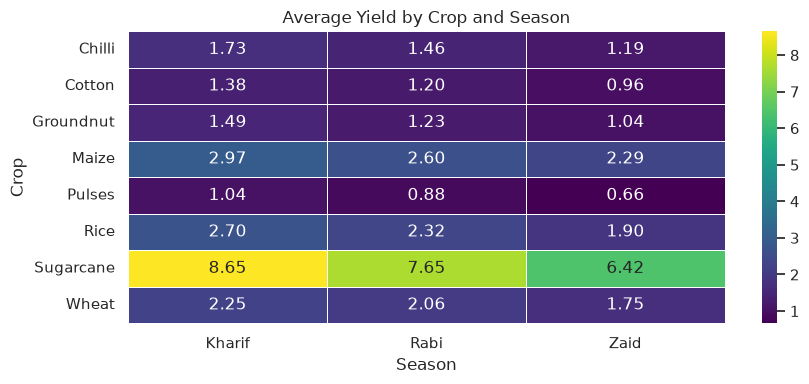

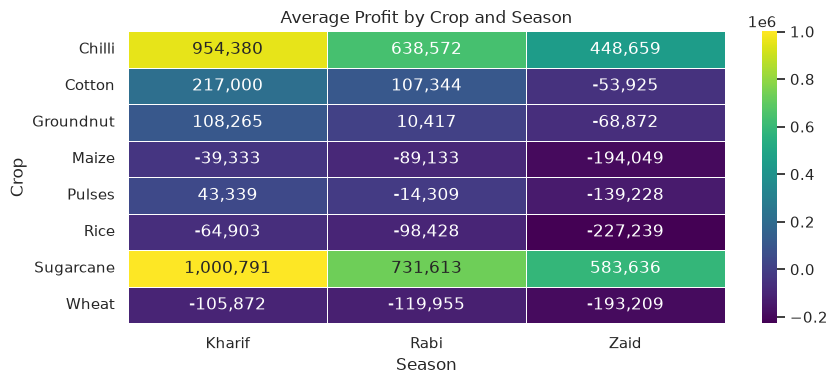

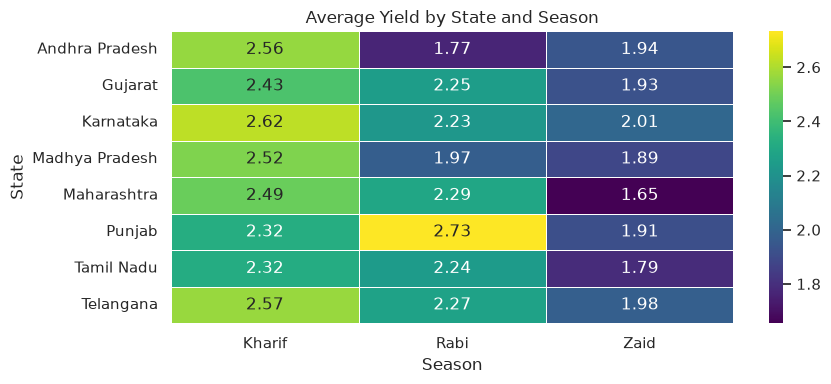

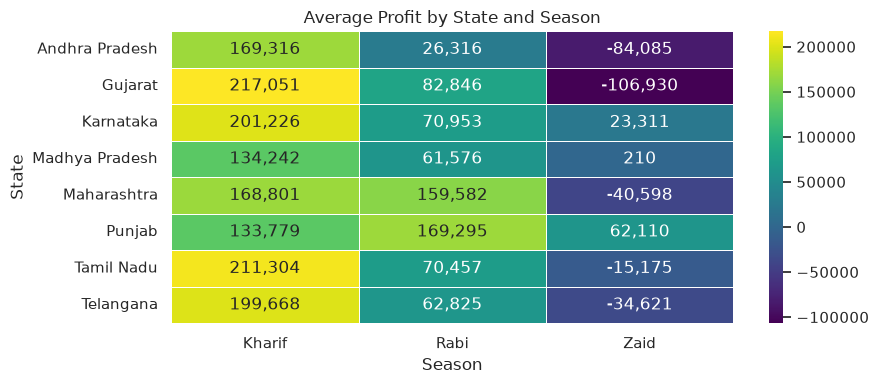

In [11]:
def heatmap_pivot(index, value, aggfunc='mean', title=None, fmt='.2f'):
    pivot = df.pivot_table(index=index, columns='Season', values=value, aggfunc=aggfunc).reindex(columns=existing_seasons)
    plt.figure(figsize=(9, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='viridis', linewidths=0.4)
    plt.title(title or f'{value} by {index} and Season')
    plt.xlabel('Season')
    plt.ylabel(index)
    plt.tight_layout()
    plt.show()
    return pivot

crop_season_yield = heatmap_pivot('Crop', 'Yield_Tonnes_Ha', title='Average Yield by Crop and Season')
crop_season_profit = heatmap_pivot('Crop', 'Profit_INR', title='Average Profit by Crop and Season', fmt=',.0f')
state_season_yield = heatmap_pivot('State', 'Yield_Tonnes_Ha', title='Average Yield by State and Season')
state_season_profit = heatmap_pivot('State', 'Profit_INR', title='Average Profit by State and Season', fmt=',.0f')


## 6. Correlation Analysis

Top Spearman correlations with yield and profit:


,Yield_Tonnes_Ha,Profit_INR
Cost_per_Tonne_INR,-0.98,-0.52
Profit_Margin_pct,0.54,0.95
Production_Tonnes,0.74,0.40
Water_Efficiency_t_per_1000m3,0.74,0.53
Revenue_INR,0.41,0.65
Market_Price_INR_Tonne,-0.58,0.20
Water_Used_m3,0.26,0.03
Rainfall_mm,0.13,0.14
Soil_Moisture_pct,0.10,0.11
Fertilizer_kg_ha,0.00,-0.10


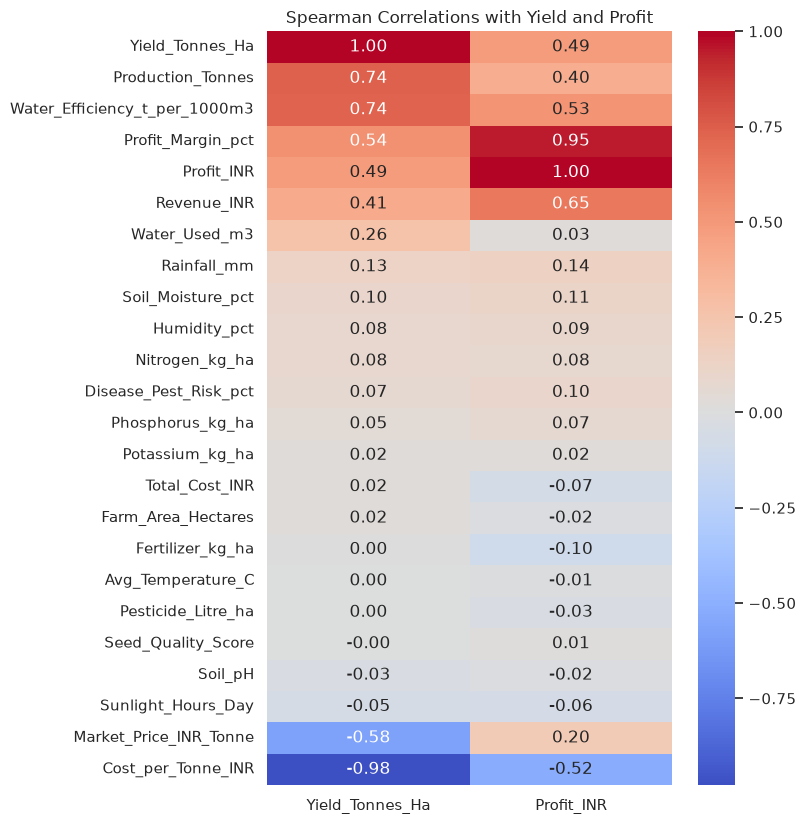

In [12]:
analysis_numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'Farm_ID']
corr = df[analysis_numeric_cols].corr(method='spearman')
target_corr = corr[['Yield_Tonnes_Ha', 'Profit_INR']].drop(index=['Yield_Tonnes_Ha', 'Profit_INR'], errors='ignore')
target_corr = target_corr.assign(max_abs_corr=target_corr.abs().max(axis=1)).sort_values('max_abs_corr', ascending=False)

print('Top Spearman correlations with yield and profit:')
display(target_corr.head(15).drop(columns='max_abs_corr'))

plt.figure(figsize=(8, max(5, 0.35 * len(analysis_numeric_cols))))
sns.heatmap(corr[['Yield_Tonnes_Ha', 'Profit_INR']].sort_values('Yield_Tonnes_Ha', ascending=False), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Spearman Correlations with Yield and Profit')
plt.tight_layout()
plt.show()


## 7. Statistical Tests

In [13]:
def kruskal_by_season(column):
    groups = [g[column].dropna().values for _, g in df.groupby('Season')]
    statistic, p_value = stats.kruskal(*groups)
    return {'metric': column, 'test': 'Kruskal-Wallis', 'statistic': statistic, 'p_value': p_value}

season_test_results = pd.DataFrame([kruskal_by_season('Yield_Tonnes_Ha'), kruskal_by_season('Profit_INR')])
display(season_test_results)

irrigation_season_table = pd.crosstab(df['Irrigation_Method'], df['Season']).reindex(columns=existing_seasons)
chi2, chi_p, chi_dof, chi_expected = stats.chi2_contingency(irrigation_season_table)
chi_square_result = pd.DataFrame([{
    'test': 'Chi-square independence',
    'variables': 'Irrigation_Method vs Season',
    'statistic': chi2,
    'degrees_of_freedom': chi_dof,
    'p_value': chi_p,
}])
print('Irrigation method x season contingency table')
display(irrigation_season_table)
display(chi_square_result)


,metric,test,statistic,p_value
0,Yield_Tonnes_Ha,Kruskal-Wallis,73.61,0.00
1,Profit_INR,Kruskal-Wallis,101.93,0.00


Irrigation method x season contingency table


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,405,370,140
Flood,590,526,194
Rainfed,463,438,140
Sprinkler,321,293,120


,test,variables,statistic,degrees_of_freedom,p_value
0,Chi-square independence,Irrigation_Method vs Season,3.51,6,0.74


## 8. Key Insights

In [14]:
season_means = df.groupby('Season').agg(
    avg_yield=('Yield_Tonnes_Ha', 'mean'),
    avg_profit=('Profit_INR', 'mean'),
    avg_cost=('Total_Cost_INR', 'mean'),
    avg_margin=('Profit_Margin_pct', 'mean'),
    avg_water_efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
).reindex(existing_seasons)

best_yield_season = season_means['avg_yield'].idxmax()
best_profit_season = season_means['avg_profit'].idxmax()
lowest_cost_season = season_means['avg_cost'].idxmin()
best_margin_season = season_means['avg_margin'].idxmax()
best_water_eff_season = season_means['avg_water_efficiency'].idxmax()

yield_driver = target_corr['Yield_Tonnes_Ha'].abs().idxmax()
profit_driver = target_corr['Profit_INR'].abs().idxmax()
yield_driver_corr = target_corr.loc[yield_driver, 'Yield_Tonnes_Ha']
profit_driver_corr = target_corr.loc[profit_driver, 'Profit_INR']

best_crop_combo = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().idxmax()
best_state_profit_combo = df.groupby(['State', 'Season'])['Profit_INR'].mean().idxmax()
yield_p = season_test_results.loc[season_test_results['metric'].eq('Yield_Tonnes_Ha'), 'p_value'].iloc[0]
profit_p = season_test_results.loc[season_test_results['metric'].eq('Profit_INR'), 'p_value'].iloc[0]

insights = [
    f"Average yield is highest in **{best_yield_season}** at {season_means.loc[best_yield_season, 'avg_yield']:.2f} tonnes/ha.",
    f"Average profit is highest in **{best_profit_season}** at INR {season_means.loc[best_profit_season, 'avg_profit']:,.0f} per farm record.",
    f"Average total cost is lowest in **{lowest_cost_season}** at INR {season_means.loc[lowest_cost_season, 'avg_cost']:,.0f}.",
    f"Profit margin is strongest in **{best_margin_season}** at {season_means.loc[best_margin_season, 'avg_margin']:.1f}% on average.",
    f"Water efficiency is highest in **{best_water_eff_season}** at {season_means.loc[best_water_eff_season, 'avg_water_efficiency']:.2f} tonnes per 1000 m3.",
    f"The strongest monotonic correlate of yield is **{yield_driver}** (Spearman r={yield_driver_corr:.2f}); the strongest correlate of profit is **{profit_driver}** (Spearman r={profit_driver_corr:.2f}).",
    f"The top crop-season yield combination is **{best_crop_combo[0]} in {best_crop_combo[1]}**; the top state-season profit combination is **{best_state_profit_combo[0]} in {best_state_profit_combo[1]}**.",
    f"Seasonal differences are {'statistically significant' if yield_p < 0.05 else 'not statistically significant'} for yield (Kruskal-Wallis p={yield_p:.3g}) and {'statistically significant' if profit_p < 0.05 else 'not statistically significant'} for profit (p={profit_p:.3g}).",
    f"Irrigation method and season are {'associated' if chi_p < 0.05 else 'not clearly associated'} by chi-square test (p={chi_p:.3g}).",
]

display(Markdown('\n'.join(f'- {item}' for item in insights)))


- Average yield is highest in **Kharif** at 2.48 tonnes/ha.
- Average profit is highest in **Kharif** at INR 178,915 per farm record.
- Average total cost is lowest in **Rabi** at INR 513,837.
- Profit margin is strongest in **Kharif** at -38.6% on average.
- Water efficiency is highest in **Kharif** at 5.89 tonnes per 1000 m3.
- The strongest monotonic correlate of yield is **Cost_per_Tonne_INR** (Spearman r=-0.98); the strongest correlate of profit is **Profit_Margin_pct** (Spearman r=0.95).
- The top crop-season yield combination is **Sugarcane in Kharif**; the top state-season profit combination is **Gujarat in Kharif**.
- Seasonal differences are statistically significant for yield (Kruskal-Wallis p=1.04e-16) and statistically significant for profit (p=7.36e-23).
- Irrigation method and season are not clearly associated by chi-square test (p=0.742).